In [58]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
SEED=42
PRINT = True

# Načtení dat

In [59]:
df = pl.read_parquet(r'kod\data\extracted\prohlidky_vozidel_stk_a_sme\parquet', schema=prohlidky_schema)
if PRINT: describe(df)

CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,Prohlidka_Ukonceni,AdministrativniOprava_CisloProtokolu,AdministrativniOprava_DatumProhlidky,Vozidlo_Vin,Vozidlo_Druh,Vozidlo_Kategorie,Vozidlo_Provedeni,Vozidlo_Znacka,Vozidlo_ObchodniOznaceni,Vozidlo_TypMotoru,Registrace_DatumPrvni,Registrace_Stat,Registrace_CisloDokladu,Emise_CisloProtokolu,Emise_DatumProhlidky,Emise_StaniceCislo,Emise_Zahajeni,Emise_Ukonceni,Emise_OdpovednaOsoba,Emise_ZakladniPalivo,Emise_AlternativniPalivo,Emise_EmisniSystem,Emise_VyrobceMotoru,Emise_CisloMotoru,Vysledek_Odometr,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,list[str],list[str],list[str]
"""CZ-520406-19-01-0001""","""2019-01-01""","""Pravidelná""",null,"""16835""","""520406""","""Středočeský kraj""","""Kolín""","""Žabonosy""","""2019-01-01T15:21:49.0770000+01…","""2019-01-01T15:40:05.4700000+01…",null,null,"""WV1ZZZ7HZ7H079425""","""NÁKLADNÍ AUTOMOBIL""","""N1""",null,"""VW""","""TRANSPORTER""","""BPC""","""2007-01-03T00:00:00.0000000+01…","""Česká republika""","""UB654181""","""CZ-520406-19-01-0001""","""2019-01-01T15:40:05.4700000+01…","""520406""","""2019-01-01T15:22:33.2900000+01…","""2019-01-01T15:39:51.5500000+01…","""16835""","""Nafta""",null,"""Řízený s OBD""",null,null,"""309068""",null,"""2021-01-01""",null,"""1""","""False""","""False""","""False""",null,null,null


(20106136, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-520406-19-01-0001,2019-01-01,Pravidelná,None,16835,520406,Středočeský kraj,Kolín,Žabonosy,2019-01-01T15:21:49.0770000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
1,CZ-420930-19-01-0001,2019-01-01,Pravidelná,None,43281,420930,Středočeský kraj,Říčany,Říčany,2019-01-01T14:35:04.4400000+01:00,...,None,2021-01-01,None,1,False,False,False,NaN,NaN,NaN
2,CZ-480811-23-01-0001,2023-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2023-01-01T12:21:49.8570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
3,CZ-420221-23-01-0004,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T17:25:41.6570000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
4,CZ-420221-23-01-0001,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:05:05.4600000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
5,CZ-420221-23-01-0003,2023-01-01,Pravidelná,None,44365,420221,Středočeský kraj,Beroun,Bavoryně,2023-01-01T16:56:47.6530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
6,CZ-170901-23-01-0001,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:23:52.2530000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
7,CZ-170901-23-01-0002,2023-01-01,Pravidelná,None,89493,170901,Olomoucký kraj,Prostějov,Bedihošť,2023-01-01T19:40:36.1970000+01:00,...,None,2025-01-01,None,1,False,False,False,NaN,NaN,NaN
8,CZ-520406-24-01-0001,2024-01-01,Pravidelná,None,1308,520406,Středočeský kraj,Kolín,Žabonosy,2024-01-01T11:30:09.4530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN
9,CZ-480811-24-01-0001,2024-01-01,Pravidelná,None,36479,480811,Olomoucký kraj,Přerov,Kojetín,2024-01-01T16:21:48.9530000+01:00,...,None,2026-01-01,None,1,False,False,False,NaN,NaN,NaN


,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-570228-21-10-0210,2 / 20 106 136,20 106 136 / 20 106 136,String
1,DatumProhlidky,2025-05-12,18 312 / 20 106 136,20 106 136 / 20 106 136,String
2,DruhProhlidky,Pravidelná,20 043 075 / 20 106 136,20 106 136 / 20 106 136,String
3,RozsahProhlidky,Plný,952 100 / 20 106 136,969 359 / 20 106 136,String
4,Prohlidka_OdpovednaOsoba,35165,68 409 / 20 106 136,20 106 136 / 20 106 136,String
5,Prohlidka_Stanice_Cislo,540514,347 272 / 20 106 136,20 106 136 / 20 106 136,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,2 958 516 / 20 106 136,20 106 136 / 20 106 136,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,2 014 789 / 20 106 136,20 106 136 / 20 106 136,String
8,Prohlidka_Stanice_Obec,Praha,2 014 789 / 20 106 136,20 106 136 / 20 106 136,String
9,Prohlidka_Zahajeni,2022-03-17T00:00:00.0000000+01:00,25 / 20 106 136,20 106 136 / 20 106 136,String


# Filtrace vozidel kategorie M1 s palivem Benzín / Nafta

In [60]:
if PRINT:
    display(df['Vozidlo_Kategorie'].value_counts(sort=True))
    display(df['Emise_ZakladniPalivo'].value_counts(sort=True))
    display(df['Emise_AlternativniPalivo'].value_counts(sort=True))

Vozidlo_Kategorie,count
str,u32
"""M1""",16408917
"""N1""",1599865
"""N3""",612147
"""M1G""",501825
"""N2""",330736
…,…
"""L1e-A""",1
"""L7e-B1""",1
"""L6e""",1


Emise_ZakladniPalivo,count
str,u32
"""Nafta""",10577800
"""Benzín""",9425359
"""CNG""",66270
"""Směs""",36014
"""LNG""",430
"""LPG""",263


Emise_AlternativniPalivo,count
str,u32
null,19649414
"""LPG""",423476
"""CNG""",33100
"""LNG""",146


In [61]:
df = df.filter(pl.col('Vozidlo_Kategorie') == 'M1', pl.col('Emise_ZakladniPalivo').is_in(['Benzín', 'Nafta']), pl.col('Emise_AlternativniPalivo').is_null())
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-550507-21-10-0341,2 / 15 934 862,15 934 862 / 15 934 862,String
1,DatumProhlidky,2025-05-12,14 774 / 15 934 862,15 934 862 / 15 934 862,String
2,DruhProhlidky,Pravidelná,15 884 707 / 15 934 862,15 934 862 / 15 934 862,String
3,RozsahProhlidky,Plný,735 859 / 15 934 862,748 639 / 15 934 862,String
4,Prohlidka_OdpovednaOsoba,35165,54 577 / 15 934 862,15 934 862 / 15 934 862,String
5,Prohlidka_Stanice_Cislo,540514,250 879 / 15 934 862,15 934 862 / 15 934 862,String
6,Prohlidka_Stanice_Kraj,Středočeský kraj,2 302 762 / 15 934 862,15 934 862 / 15 934 862,String
7,Prohlidka_Stanice_ORP,Hlavní město Praha,1 654 630 / 15 934 862,15 934 862 / 15 934 862,String
8,Prohlidka_Stanice_Obec,Praha,1 654 630 / 15 934 862,15 934 862 / 15 934 862,String
9,Prohlidka_Zahajeni,2025-11-03T08:37:33.2830000+01:00,7 / 15 934 862,15 934 862 / 15 934 862,String


# Přetypování sloupců

In [62]:
if PRINT:
    print('Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu')
    short_display(df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu')))
df = cast_prohlidka(df)

Záznamy, kde neodpovídá CisloProtokolu a Emise_CisloProtokolu
(748639, 2)


,CisloProtokolu,Emise_CisloProtokolu
0,CZ-3848-19-02-0017,CZ-003848-19-02-0017
1,CZ-3848-19-02-0012,CZ-003848-19-02-0012
2,CZ-3848-19-02-0003,CZ-003848-19-02-0003
3,CZ-3848-19-02-0010,CZ-003848-19-02-0010
4,CZ-3848-19-02-0014,CZ-003848-19-02-0014
5,CZ-3848-19-02-0011,CZ-003848-19-02-0011
6,CZ-3848-19-02-0006,CZ-003848-19-02-0006
7,CZ-3848-19-02-0002,CZ-003848-19-02-0002
8,CZ-3618-21-02-0101,CZ-003618-21-02-0101
9,CZ-3706-21-02-0051,CZ-003706-21-02-0051


# Odstranění nekonzistentních CiselProtokolu

In [63]:
inconsistent_cislo_protokolu = df[['CisloProtokolu', 'Emise_CisloProtokolu']].filter(pl.col('CisloProtokolu') != pl.col('Emise_CisloProtokolu'))['CisloProtokolu'].to_list()
print(inconsistent_cislo_protokolu)
df = df.filter(~pl.col('CisloProtokolu').is_in(inconsistent_cislo_protokolu))

['CZ-3420-24-02-0512', 'CZ-3420-24-02-0563', 'CZ-3420-24-02-0561']


# Odstranění duplicitních čísel protokolu

In [64]:
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))
df = df.unique()
if PRINT: short_display(df.filter(pl.col('CisloProtokolu').count().over('CisloProtokolu') > 1).sort('CisloProtokolu'))

(1340, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C
0,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
1,CZ-110301-25-03-0153,2025-03-26,Pravidelná,None,101929,110301,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:29.103,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
2,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
3,CZ-110503-25-03-0726,2025-03-26,Pravidelná,None,82867,110503,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 14:03:43.330,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
4,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
5,CZ-110802-25-03-0421,2025-03-26,Pravidelná,None,112949,110802,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:52:44.957,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
6,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
7,CZ-110901-21-10-0224,2021-10-12,Pravidelná,None,55017,110901,Hlavní město Praha,Hlavní město Praha,Praha,2021-10-12 07:57:03.890,...,None,2023-10-12,None,1,False,False,False,NaN,NaN,NaN
8,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN
9,CZ-110905-25-03-0145,2025-03-26,Pravidelná,None,912,110905,Hlavní město Praha,Hlavní město Praha,Praha,2025-03-26 13:59:10.907,...,None,2027-03-26,None,1,False,False,False,NaN,NaN,NaN


(0, 45)


,CisloProtokolu,DatumProhlidky,DruhProhlidky,RozsahProhlidky,Prohlidka_OdpovednaOsoba,Prohlidka_Stanice_Cislo,Prohlidka_Stanice_Kraj,Prohlidka_Stanice_ORP,Prohlidka_Stanice_Obec,Prohlidka_Zahajeni,...,Vysledek_Poznamka,Vysledek_DatumPristiProhlidky,Vysledek_NalepkaVylepena,Vysledek_Celkovy,TechnickaCast_Pritomno,AdrCast_Pritomno,TskCast_Pritomno,Zavady_A,Zavady_B,Zavady_C


# Odstranění vybraných sloupců
- nerelevantních sloupců
- sloupců přítomných v jiných datových sadách s vyšší kvalitou

In [65]:
irrelevant_columns = ['Registrace_CisloDokladu', 'Vozidlo_Kategorie', 'Emise_CisloProtokolu', 'Emise_AlternativniPalivo', 'Emise_EmisniSystem', 'Vysledek_Poznamka', 'Vysledek_DatumPristiProhlidky', 'Vysledek_Celkovy']
duplicate_columns = ['Emise_DatumProhlidky', 'Emise_StaniceCislo', 'Emise_Zahajeni', 'Emise_Ukonceni', 'Emise_OdpovednaOsoba', 'Emise_VyrobceMotoru', 'Emise_CisloMotoru']
df = df.drop(irrelevant_columns + duplicate_columns)

In [66]:
if PRINT:
    print(f'Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: {df.filter(pl.col('RozsahProhlidky').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')
    print(f'Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: {df.filter(pl.col('Vysledek_NalepkaVylepena').is_not_null()).select((pl.col('TechnickaCast_Pritomno') == False).sum()).item()}.')

df = df.drop('RozsahProhlidky')
df = df.drop('Vysledek_NalepkaVylepena')

Pocet zanamu obsahujicich RozsahProhlidky bez TechnickeCasti_Pritomno: 0.
Pocet zanamu obsahujicich Vysledek_NalepkaVylepena bez TechnickeCasti_Pritomno: 0.


In [67]:
if PRINT: schema_description(df)

,column,majority_class,majority_cnt,non_null,dtype
0,CisloProtokolu,CZ-430832-23-11-0258,1 / 15 934 189,15 934 189 / 15 934 189,String
1,DatumProhlidky,2025-05-12,14 774 / 15 934 189,15 934 189 / 15 934 189,Date
2,DruhProhlidky,Pravidelná,15 884 034 / 15 934 189,15 934 189 / 15 934 189,String
3,Prohlidka_OdpovednaOsoba,35165,54 575 / 15 934 189,15 934 189 / 15 934 189,Int32
4,Prohlidka_Stanice_Cislo,540514,250 876 / 15 934 189,15 934 189 / 15 934 189,Int32
5,Prohlidka_Stanice_Kraj,Středočeský kraj,2 302 688 / 15 934 189,15 934 189 / 15 934 189,String
6,Prohlidka_Stanice_ORP,Hlavní město Praha,1 654 563 / 15 934 189,15 934 189 / 15 934 189,String
7,Prohlidka_Stanice_Obec,Praha,1 654 563 / 15 934 189,15 934 189 / 15 934 189,String
8,Prohlidka_Zahajeni,2025-11-03 08:37:33.283000,7 / 15 934 189,15 934 189 / 15 934 189,"Datetime(time_unit='us', time_zone=None)"
9,Prohlidka_Ukonceni,2019-04-11 10:15:00,6 / 15 934 189,15 934 189 / 15 934 189,"Datetime(time_unit='us', time_zone=None)"


# Zapracování administrativních oprav
## Identifikace změn

In [68]:
# Definice ignorovaných sloupců
ignore_cols = [
    'Prohlidka_Zahajeni', 
    'Prohlidka_Ukonceni', 
    'AdministrativniOprava_CisloProtokolu', 
    'AdministrativniOprava_DatumProhlidky',
    'CisloProtokolu'
]

# Filtrace oprav
df_opravy = df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())

# Join opravy na originál
df_diff = df_opravy.join(
    df.select(pl.all().name.suffix('_Original')),
    left_on='AdministrativniOprava_CisloProtokolu',
    right_on='CisloProtokolu_Original',
    how='left'
)

# Detekce změn
cols_to_compare = [c for c in df.columns if c not in ignore_cols]
diff_list = []

for col in cols_to_compare:
    col_orig = f"{col}_Original"
    
    if col_orig in df_diff.columns:
        # Funkce pro bezpečný převod na String
        def safe_cast_to_str(c_name):
            dtype = df_diff.schema[c_name]
            # Pokud je to List, spojíme prvky do stringu, jinak klasický cast
            if isinstance(dtype, pl.List):
                return pl.col(c_name).list.join(", ").cast(pl.Utf8)
            else:
                return pl.col(c_name).cast(pl.Utf8)

        # Filtrace změn (porovnání funguje i pro Listy)
        changes = df_diff.filter(
            (pl.col(col) != pl.col(col_orig)) | 
            (pl.col(col).is_null() != pl.col(col_orig).is_null())
        ).select([
            pl.col('CisloProtokolu').alias('Protokol_Opravy'),
            pl.col('AdministrativniOprava_CisloProtokolu').alias('Opravovany_Protokol'),
            pl.lit(col).alias('Zmeneny_Parametr'),
            safe_cast_to_str(col_orig).alias('Puvodni_Hodnota'),
            safe_cast_to_str(col).alias('Nova_Hodnota')
        ])
        
        if not changes.is_empty():
            diff_list.append(changes)

# Sjednocení
final_diff_table = pl.concat(diff_list).sort(['Opravovany_Protokol', 'Protokol_Opravy'])
if PRINT: display(final_diff_table)

Protokol_Opravy,Opravovany_Protokol,Zmeneny_Parametr,Puvodni_Hodnota,Nova_Hodnota
str,str,str,str,str
"""CZ-110301-22-10-0064""","""CZ-110301-22-10-0062""","""Vozidlo_TypMotoru""","""F5LM""","""S63B44B"""
"""CZ-110301-23-01-0032""","""CZ-110301-23-01-0030""","""Vysledek_Odometr""","""789580""","""78580"""
"""CZ-110301-23-03-0056""","""CZ-110301-23-03-0055""","""Vysledek_Odometr""",null,"""175658"""
"""CZ-110301-23-03-0056""","""CZ-110301-23-03-0055""","""DatumProhlidky""","""2023-03-23""","""2023-03-24"""
"""CZ-110301-23-03-0057""","""CZ-110301-23-03-0055""","""DatumProhlidky""","""2023-03-23""","""2023-03-24"""
…,…,…,…,…
"""CZ-910420-19-05-0014""","""CZ-910420-19-05-0012""","""Vozidlo_Vin""","""TBMCC73T7B9030999""","""TMBCC73T7B9030999"""
"""CZ-910420-19-10-0041""","""CZ-910420-19-10-0040""","""Vozidlo_Vin""","""WV1ZZZ7HZKHO45856""","""WV1ZZZ7HZKH045856"""
"""CZ-910420-21-08-0017""","""CZ-910420-21-08-0014""","""DatumProhlidky""","""2021-08-16""","""2021-08-17"""


## Vykreslení nejčastěji měněných

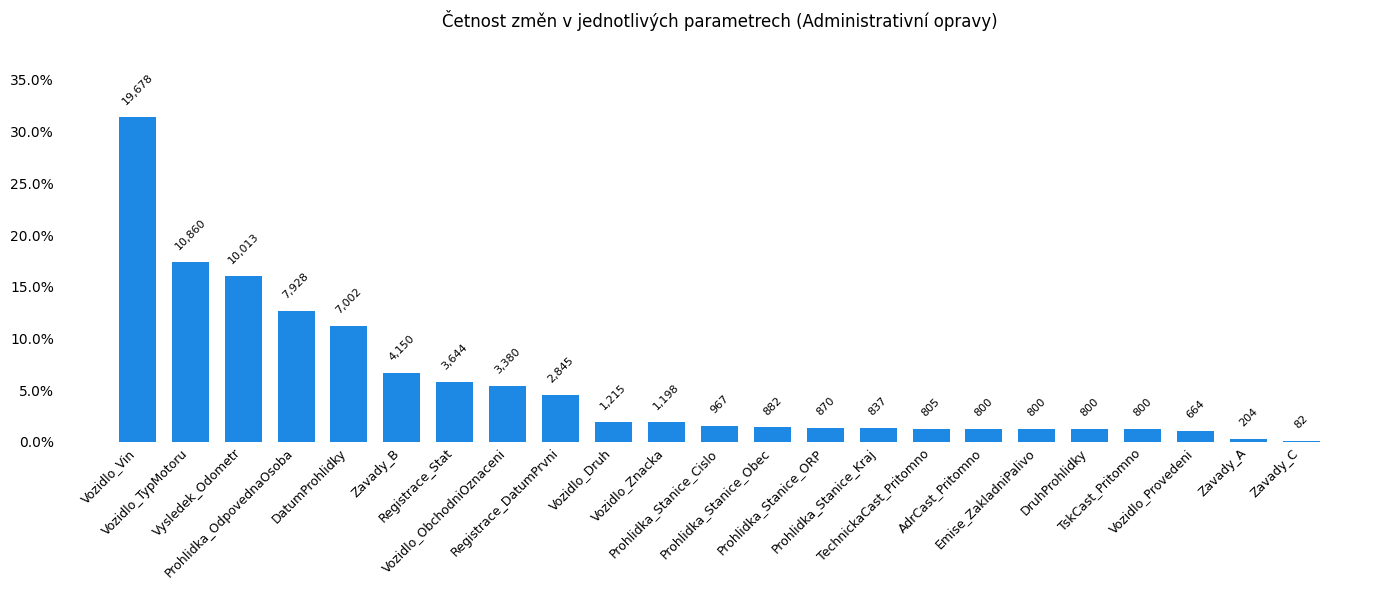

In [69]:
# Agregace počtu změn na parametr
summary = final_diff_table.group_by('Zmeneny_Parametr').len().sort('len', descending=True)

columns = summary['Zmeneny_Parametr'].to_list()
counts = summary['len'].to_list()
total_revisions = df_opravy.height
ratios = [c / total_revisions if total_revisions > 0 else 0 for c in counts]

# Inicializace grafu
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(columns, ratios, color='#1e88e5', width=0.7)

# Horní popisky s čárkou
for i, count in enumerate(counts):
    ax.text(i, ratios[i] + 0.01, f"{count:,}", ha='center', va='bottom', rotation=45, fontsize=8)

# Dynamické nastavení limitu osy Y (max hodnota + 25 % prostor pro popisky)
max_ratio = max(ratios) if ratios else 0
ax.set_ylim(0, max_ratio * 1.25 if max_ratio > 0 else 1.2)

# Formátování os a vzhledu
ax.set_title('Četnost změn v jednotlivých parametrech (Administrativní opravy)')
ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

# Odstranění linií grafu
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.tight_layout()
plt.savefig("kod/explorace/administrativni_opravy.svg", format="svg", bbox_inches='tight')
if PRINT: plt.show()

## Zanesení administrativních oprav

In [70]:
# Definice polí, která zůstávají v původním stavu
protected_cols = [
    'CisloProtokolu',
    'Prohlidka_Zahajeni', 
    'Prohlidka_Ukonceni', 
    'AdministrativniOprava_CisloProtokolu', 
    'AdministrativniOprava_DatumProhlidky'
]

# Sloupce určené k přepsání daty z oprav
update_cols = [c for c in df.columns if c not in protected_cols]

# Získání posledních verzí oprav pro každý protokol
latest_corrections = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_not_null())
    .sort('AdministrativniOprava_DatumProhlidky')
    .group_by('AdministrativniOprava_CisloProtokolu', maintain_order=True)
    .last()
    .with_columns(pl.lit(True).alias('_has_correction'))
)

# Aplikace oprav na originální záznamy
df = (
    df.filter(pl.col('AdministrativniOprava_CisloProtokolu').is_null())
    .join(
        latest_corrections.select(
            ['AdministrativniOprava_CisloProtokolu', '_has_correction'] + 
            [pl.col(c).alias(f"{c}_Latest") for c in update_cols]
        ),
        left_on='CisloProtokolu',
        right_on='AdministrativniOprava_CisloProtokolu',
        how='left'
    )
    .with_columns([
        # Nahrazení hodnotou z opravy, pokud existuje (včetně null hodnot)
        pl.when(pl.col('_has_correction').fill_null(False))
        .then(pl.col(f"{c}_Latest"))
        .otherwise(pl.col(c))
        .alias(c)
        for c in update_cols
    ])
    .select(df.columns)
    .select(pl.exclude(['AdministrativniOprava_CisloProtokolu', 'AdministrativniOprava_DatumProhlidky']))
)

# Chybějící hodnoty

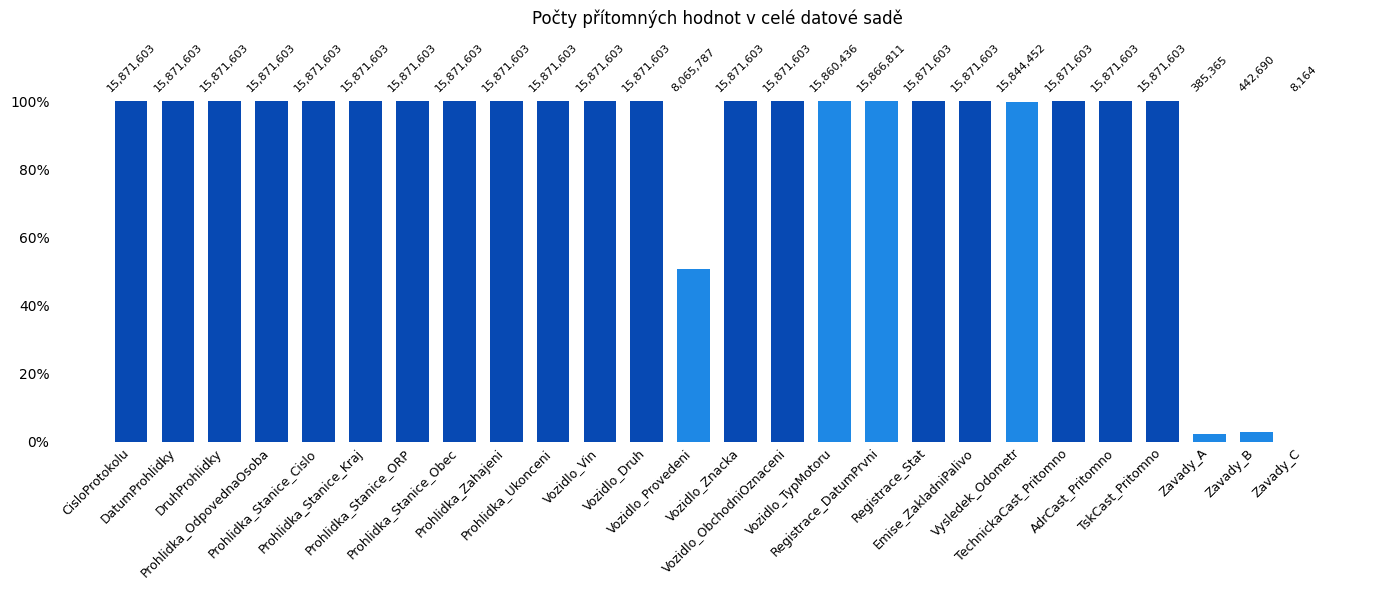

In [71]:
# Výpočet metrik
total_rows = len(df)
columns = df.columns
null_counts = df.null_count().row(0)
non_null_counts = [total_rows - count for count in null_counts]
ratios = [count / total_rows if total_rows > 0 else 0 for count in non_null_counts]

# Definice barev
colors = ['#0749b3' if r == 1.0 else '#1e88e5' for r in ratios]

# Inicializace grafu
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(columns, ratios, color=colors, width=0.7)

# Horní popisky
for i, count in enumerate(non_null_counts):
    ax.text(i, 1.02, f"{count:,}", ha='center', va='bottom', rotation=45, fontsize=8)

# Formátování
ax.set_title('Počty přítomných hodnot v celé datové sadě')
ax.set_ylim(0, 1.2)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(axis='both', which='both', length=0)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.tight_layout()
plt.savefig("kod/explorace/prohlidky_pritomne_hodnoty.svg", format="svg", bbox_inches='tight')
plt.show()